# Resolución de la dinámica en forma simbólica

Se presenta un algoritmo simple para resolver la dinámica por Euler Lagrange
Luego se aplica a un péndulo Furuta y se muestra el resultado de la integración numérica para calcular la trayectoria en el espacio de operación

In [1]:
import numpy as np
import sympy as sp
from IPython.display import display, Math
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
import matplotlib
%matplotlib inline

print(matplotlib.get_backend())


inline


## Cinemática simbólica

Método aplicable a cualquier robot serie

In [2]:
def fkine_symbolic(DH):
    """
    Cinemática directa con parámetros DH distales.

    Parámetros:
    -----------
    DH : lista de diccionarios
        Cada elemento corresponde a {'a':..., 'd':..., 'alpha':..., 'theta':..., 'joint_type':... }.
        Los valores pueden ser constantes o simbólicos.
        joint_type : tipo de articulación ('r' o 'p').

    Retorna:
    --------
    q : vector de variables articulares simbólicas
    A_list : lista con matrices homogéneas A_i (de i-1 a i)
    W_list : lista con matrices homogéneas acumuladas (0 hasta i)
    """

    N_axis = len(DH)

    # Defino variables articulares simbólicas
    q = sp.symbols(f'q1:{N_axis+1}', real=True)

    # Construyo matrices A_i
    A_list = []
    W_list = []

    for i in range(0,N_axis):
        theta = DH[i].get('theta', sp.symbols(f"theta{i+1}", real=True))
        d     = DH[i].get('d',     sp.symbols(f"d{i+1}", real=True))
        a     = DH[i].get('a',     sp.symbols(f"a{i+1}", real=True))
        alpha = DH[i].get('alpha', sp.symbols(f"alpha{i+1}", real=True))

        # Sustituyo según tipo de articulación
        if DH[i].get('joint_type') == 'r':   # rotacional → theta = q[i]
            theta = q[i]
        elif DH[i].get('joint_type') == 'p': # prismática → d = q[i]
            d = q[i]

        A = sp.Matrix([
            [sp.cos(theta), -sp.sin(theta)*sp.cos(alpha),  sp.sin(theta)*sp.sin(alpha), a*sp.cos(theta)],
            [sp.sin(theta),  sp.cos(theta)*sp.cos(alpha), -sp.cos(theta)*sp.sin(alpha), a*sp.sin(theta)],
            [0,                      sp.sin(alpha),                      sp.cos(alpha),               d],
            [0,                      0,                                      0,                       1]
        ])
        A = sp.simplify(A)
        A = sp.nsimplify(A, tolerance=1e-12)
        A_list.append(A)

        if i == 0:
            W_list.append(A)
        else:
            W_list.append(sp.simplify(W_list[-1]*A))

    return A_list, W_list, q


In [3]:
def inv_SE3(T):
    R = T[:3, :3]
    p = T[:3, 3]

    R_T = R.T
    p_new = -R_T @ p

    T_inv = sp.eye(4)
    T_inv[:3, :3] = R_T
    T_inv[:3, 3] = p_new

    return T_inv

def calcAij(A, i, j):
        """
        Calcula la transformación entre i y j usando lista de matrices A_i.

        Parámetros:
            A : list of sympy.Matrix (A[0] = A1 en MATLAB)
            i, j : índices (base 0)
            simplify_result : bool (opcional, evitar por defecto)

        Retorna:
            Aij : sympy.Matrix
        """

        # convertir a índices Python
        i -= 1
        j -= 1

        # Determinar sentido
        if i < j:
            ss = -1
            k_idx = list(range(i, j+1))
        elif i > j:
            ss = 1
            k_idx = list(range(j, i+1))
        else:
            return sp.eye(4)

        # Producto
        Aij = sp.eye(4)

        for k in range(1, len(k_idx)):
            Aij = Aij @ A[k_idx[k]]

        # Inversión si corresponde
        if ss == -1:
            Aij = inv_SE3(Aij)

        Aij = sp.simplify(Aij)
        return Aij


def jacobian_symbolic(DH, A, oJv, pJv, pJw):
    """
    Jacobiano simbólico

    Parámetros:
        DH : parámetros cinemáticos del robot
        A : lista de matrices homogéneas (A[0] = A1)
        oJv, pJv, pJw : índices de frames (base 0)
    """

    J = sp.zeros(6, len(DH))

    for iq in range(len(DH)):

        is_revolute = (DH[iq].get('joint_type') == 'r')

        Aojv = calcAij(A, oJv, iq)
        Apjv = calcAij(A, pJv, iq)
        Apjw = calcAij(A, pJw, iq)

        # --- bloque lineal ---
        p = Aojv[:3, 3]

        for ic in range(3):
            if is_revolute:
                r = Apjv[:3, ic]
                v_aux = p.cross(r)
            else:
                v_aux = Apjw[:3, ic]

            J[ic, iq] = sp.simplify(v_aux[2])

        # --- bloque angular ---
        for ic in range(3):
            if is_revolute:
                r = Apjw[:3, ic]
                J[ic+3, iq] = sp.simplify(r[2])
            else:
                J[ic+3, iq] = 0

    return J

## Dinámica simbólica

Método aplicable a cualquier robot serie

In [4]:
def dynamics_lagrange(DH, A_list, W_list, q, g_vec,dyn_params, Kmethod='trace'):
    """
    Calcula las matrices dinámicas M, C y el vector G de un robot genérico
    usando el formalismo de Lagrange y los parámetros dinámicos.

    Parámetros:
    -----------
    DH :
    A_list:
    W_list : list of sympy.Matrix
        Lista de transformaciones homogéneas acumuladas (de la base hasta cada eslabón).
    q : list of sympy.Symbol
        Vector de coordenadas articulares.
    g_vec : sympy.Matrix
        Vector de gravedad (ej: sp.Matrix([0, -9.81, 0]) para gravedad en -y).

    Retorna:
    --------
    M : sympy.Matrix
        Matriz de inercia.
    C : sympy.Matrix
        Matriz centrífuga/coriolis.
    G : sympy.Matrix
        Vector de gravedad.
    """

    N_axis = len(q)

    # Variables simbólicas: velocidades y aceleraciones
    q_p  = sp.symbols(f'qp_1:{N_axis+1}', real=True)
    q_2p = sp.symbols(f'q2p_1:{N_axis+1}', real=True)

    # Construyo matrices de pseudoinercia
    I_list = []
    Io_list = []
    mrg_list = []
    m_list = []
    for i in range(N_axis):
        Ioxx = dyn_params[i].get('Ioxx', sp.symbols(f"Ioxx{i+1}", real=True))
        Ioyy = dyn_params[i].get('Ioyy', sp.symbols(f"Ioyy{i+1}", real=True))
        Iozz = dyn_params[i].get('Iozz', sp.symbols(f"Iozz{i+1}", real=True))
        Ioxy = dyn_params[i].get('Ioxy', sp.symbols(f"Ioxy{i+1}", real=True))
        Ioxz = dyn_params[i].get('Ioxz', sp.symbols(f"Ioxz{i+1}", real=True))
        Ioyz = dyn_params[i].get('Ioyz', sp.symbols(f"Ioyz{i+1}", real=True))
        m = dyn_params[i].get('m', sp.symbols(f"m{i+1}", real=True))
        xg = dyn_params[i].get('xg', sp.symbols(f"xg{i+1}", real=True))
        yg = dyn_params[i].get('yg', sp.symbols(f"yg{i+1}", real=True))
        zg = dyn_params[i].get('zg', sp.symbols(f"zg{i+1}", real=True))

        # Matriz de pseudoinercia
        Ii = sp.Matrix([
            [(Ioyy+Iozz-Ioxx)/2,                  -Ioxy,                    -Ioxz, m*xg],
            [             -Ioxy,     (Ioxx+Iozz-Ioyy)/2,                    -Ioyz, m*yg],
            [             -Ioxz,                  -Ioyz,       (Ioxx+Ioyy-Iozz)/2, m*zg],
            [               m*xg,                  m*yg,                      m*zg,   m]
        ])
        I_list.append(Ii)

        # Matriz de inercia
        IIi = sp.Matrix([
            [Ioxx, Ioxy, Ioxz],
            [Ioxy, Ioyy, Ioyz],
            [Ioxz, Ioyz, Iozz] ])
        Io_list.append(IIi)

        mrg = m*sp.Matrix([xg, yg, zg, 1])
        mrg_list.append(mrg)

        m_list.append(m)


    if Kmethod == 'trace':
        # --- Cálculo de M ---
        print("Calculando M según método de la traza...")
        M = sp.zeros(N_axis, N_axis)
        for i in range(N_axis):
            for j in range(N_axis):
                val = 0
                for k in range(N_axis):
                    dW1 = sp.diff(W_list[k], q[i])
                    dW2 = sp.diff(W_list[k], q[j])
                    val += sp.trace(dW1 * I_list[k] * dW2.T)
                M[i,j] = sp.simplify(val)
                #M[i,j] = sp.nsimplify(M[i,j], tolerance=1e-12)
    else:
        # --- Cálculo de M ---
        print("Calculando M según método de robótica ...")
        M = sp.zeros(N_axis, N_axis)
        for i in range(N_axis):
            Ji = jacobian_symbolic(DH, A_list, i+1, i+1, i+1)
            Jvi = Ji[0:3, 0:i+1]
            Jwi = Ji[3:6, 0:i+1]

            # padding de ceros
            if i < N_axis:
                Jvi = Jvi.row_join(sp.zeros(3, N_axis - (i+1)))
                Jwi = Jwi.row_join(sp.zeros(3, N_axis - (i+1)))

            skew_rgi = get_skew(sp.Matrix(mrg_list[i][0:3]))

            Mi = sp.simplify(
                m_list[i] * (Jvi.T * Jvi)
                + Jwi.T * Io_list[i] * Jwi
                - Jvi.T * skew_rgi * Jwi
                + Jwi.T * skew_rgi * Jvi
            )

            M += Mi

        M = sp.simplify(M)
    print('OK')

    # --- Cálculo de C ---
    print("Calculando C ...")
    C = sp.zeros(N_axis, N_axis)
    for s in range(N_axis):
        for j in range(N_axis):
            val = 0
            for k in range(N_axis):
                dW1 = sp.diff(M[s,j], q[k])
                dW2 = sp.diff(M[s,k], q[j])
                dW3 = sp.diff(M[j,k], q[s])
                h = (dW1 + dW2 - dW3)/2
                val += h * q_p[k]
            C[s,j] = sp.simplify(val)
            #C[i,j] = sp.nsimplify(C[s,j], tolerance=1e-12)

    # --- Cálculo de G ---
    print("Calculando G ...")
    G = sp.zeros(N_axis, 1)
    for s in range(N_axis):
        val = 0
        for k in range(s, N_axis):
            dW4 = sp.diff(W_list[k], q[s])
            val += -sp.Matrix.hstack(g_vec.T, sp.Matrix([1])).dot(dW4 * mrg_list[k])
        G[s] = sp.simplify(val)
        #G[s] = sp.nsimplify(G[s], tolerance=1e-12)

    return M, C, G, q_p, q_2p


def get_skew(v):
    """
    Devuelve la matriz skew-simétrica de un vector 3x1

    Parámetros:
    -----------
    v : iterable o Matrix (3,)

    Retorna:
    --------
    3x3 Matrix (skew)
    """
    v = sp.Matrix(v)

    return sp.Matrix([
        [0,     -v[2],  v[1]],
        [v[2],   0,    -v[0]],
        [-v[1],  v[0],  0]
    ])


# Péndulo de Furuta
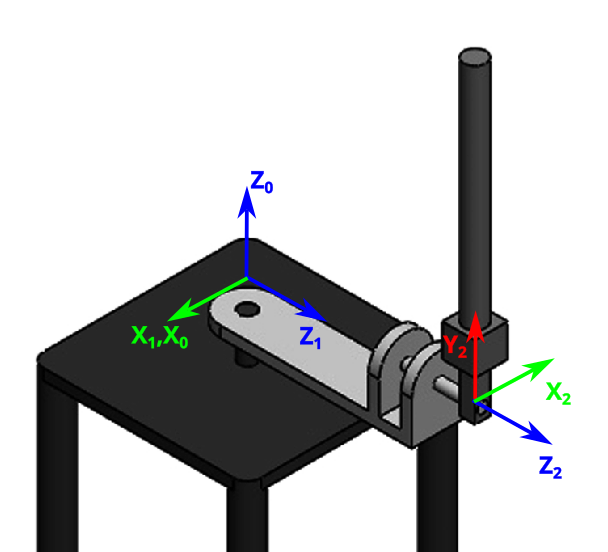

In [5]:
# Definición de los parámetros cinemáticos y dinámicos del robot
# Los que quiero dejar como parámetro, no deben tener especificado valor
DH_params = {
    0: {'theta':0, 'alpha': -np.pi/2, 'a': 0, 'd':0, 'joint_type':'r'},
    1: {'theta':0 ,'alpha': 0, 'a':0, 'joint_type':'r'}
}

dyn_params  = {
    0:{'Ioxy': 0, 'Ioxz': 0, 'Ioyz': 0, 'yg': 0, 'xg': 0},
    1:{'Ioxy': 0, 'Ioxz': 0, 'Ioyz': 0, 'xg': 0, 'zg': 0}
}

# Montaje
g_vec = sp.Matrix([0, 0, -9.81])


# Cálculo de la cinemática directa simbólica
print("Calculando cinemática directa ...")
A_list, W_list, q = fkine_symbolic(DH_params)
print("POSE(q)=")
sp.pretty_print(W_list[-1])
print("Variables articulares:", q)

# Cálculo de las matrices de la dinámica
print("Calculando las matrices de la dinámica ...")
M, C, G, q_p, q_2p = dynamics_lagrange(DH_params, A_list, W_list, q, g_vec, dyn_params,Kmethod='robotics')


print("Matriz M:")
sp.pprint(M)
print("\nMatriz C:")
sp.pprint(C)
print("\nVector G:")
sp.pprint(G)



Calculando cinemática directa ...
POSE(q)=
⎡cos(q₁)⋅cos(q₂)  -sin(q₂)⋅cos(q₁)  -sin(q₁)  -d₂⋅sin(q₁)⎤
⎢                                                        ⎥
⎢sin(q₁)⋅cos(q₂)  -sin(q₁)⋅sin(q₂)  cos(q₁)   d₂⋅cos(q₁) ⎥
⎢                                                        ⎥
⎢   -sin(q₂)          -cos(q₂)         0           0     ⎥
⎢                                                        ⎥
⎣       0                0             0           1     ⎦
Variables articulares: (q1, q2)
Calculando las matrices de la dinámica ...
Calculando M según método de robótica ...
OK
Calculando C ...
Calculando G ...
Matriz M:
⎡         2                        2         2                      ⎤
⎢Ioxx₂⋅sin (q₂) + Ioyy₁ + Ioyy₂⋅cos (q₂) + d₂ ⋅m₂  d₂⋅m₂⋅yg₂⋅cos(q₂)⎥
⎢                                                                   ⎥
⎣               d₂⋅m₂⋅yg₂⋅cos(q₂)                        Iozz₂      ⎦

Matriz C:
⎡qp₂⋅(Ioxx₂ - Ioyy₂)⋅sin(2⋅q₂)                                                 ↪
⎢───────

In [7]:
# Resolución para el segundo eslabón, pensando que está libre (péndulo subactuado)
tau2 = (M[1,:]*sp.Matrix(q_2p))[0] + (C[1,:]*sp.Matrix(q_p))[0] + G[1]
#display(Math(sp.latex(tau2)))

sol = sp.solve(tau2, q_2p[1])
#print("Modelo no lineal de la dinámica del segundo eslabón:\n\n",sol)

print("\n\nModelo no lineal de la dinámica del segundo eslabón:\n\n")
latex_fml = sp.latex(
        sol,
        symbol_names={
            q_p[0]: r'\dot{q}_1',
            q_2p[0]: r'\ddot{q}_1',
            q_p[1]: r'\dot{q}_2',
            q_2p[1]: r'\ddot{q}_2',
        }
    )
display(Math(latex_fml))





Modelo no lineal de la dinámica del segundo eslabón:




<IPython.core.display.Math object>

## Modelo numérico

In [8]:

ae = 0.2    # Largo del eslabon 2
be = 0.02   # Sección del eslabón 2
masa2 = 0.5
Ig2xx = masa2*(ae**2+be**2)/12
Ig2yy = masa2*(be**2)/6
Ig2zz = masa2*(ae**2+be**2)/12
yg2 = 0.1


#  Preparo un modelo numérico para simulación
symbols = {
    str(s): s
    for s in sol[0].free_symbols
}

# Reemplazamos los símbolos por sus valores numéricos
parametros = {
    symbols['Ioxx2']: Ig2xx + masa2*yg2**2,
    symbols['Ioyy2']: Ig2yy,
    symbols['Iozz2']: Ig2zz + masa2*yg2**2,
    symbols['m2']: masa2,
    symbols['yg2']: yg2,
    symbols['d2']: 0.2,
}

sol_num = sol[0].subs(parametros)
print(sol_num)
ddq2 = sp.lambdify((q[1], q_p[0], q_2p[0]),sol_num)

# El estado es la posición y velocidad del eslabon 2
# Pero agrego la velocidad del 1 porque entro con aceleracion angular 1 y necesito integrar
def dxdt(t, x, u):
    q2, qp_2, qp_1 = x
    q2p_1 = u(t, x)

    return [
        qp_2,
        ddq2(q2, qp_1, q2p_1)-1*qp_2,
        q2p_1
    ]



-1.49625935162095*q2p_1*cos(q2) + 0.497506234413965*qp_1**2*sin(2.0*q2) - 73.3915211970075*sin(q2)


## Simulación

Text(0.5, 0, 'Tiempo [s]')

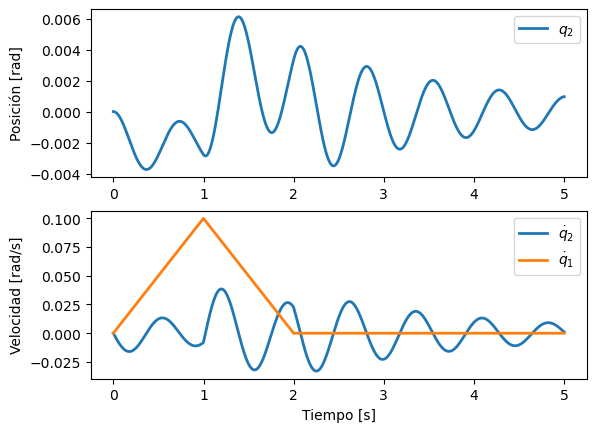

In [9]:
# Parámetros de la simulación
Ts = 0.001
# Estado inicial del péndulo
x0 = np.r_[0,0,0]
t_span = [0, 5]
# Armo la base de tiempo para las muestras
t = np.arange(t_span[0], t_span[1]+Ts, Ts)

# Ejemplo: torques nulos
def u_func(t, x):
    if t<1:
        acel=0.1
    elif t<2:
        acel=-0.1
    else:
        acel=0
    return acel

ode_sol = solve_ivp(dxdt, t_span, x0, args=(u_func,), max_step=0.01, t_eval=t)
plt.subplot(2,1,1)
plt.plot(ode_sol.t,ode_sol.y[0,:].T,lw=2)
plt.legend(['$q_2$'])
plt.ylabel('Posición [rad]')
plt.subplot(2,1,2)
plt.plot(ode_sol.t,ode_sol.y[1:3,:].T,lw=2)
plt.legend([r'$\dot{q}_2$',r"$\dot{q}_1$"])
plt.ylabel('Velocidad [rad/s]')
plt.xlabel('Tiempo [s]')
